# Cohort Analysis: A Product Analytics Deep Dive

Cohort analysis is a behavioral analytics technique that segments users into groups (cohorts) based on shared characteristics or experiences within a defined time period. This notebook explores four distinct methods to analyze user cohorts and understand their lifecycle patterns.

## What is Cohort Analysis?

A cohort is a group of users who share a common characteristic or experience within a defined time period. Cohort analysis helps product managers and analysts answer critical questions:

- **User Retention**: How long do users stay active?
- **Lifecycle Trends**: Do newer cohorts behave differently?
- **Feature Impact**: How does a feature change affect user behavior?
- **Revenue Growth**: How does monetization vary by cohort?

**Why Use Cohort Analysis?**
- Isolates user behavior by signup time (removes confounding variables)
- Reveals trends invisible in aggregate metrics
- Enables A/B testing and comparing product changes
- Identifies early warning signs of product-market fit issues

## Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Color palette
colors = ['#2E86AB', '#F18F01', '#2CA58D', '#E15554']
color_dict = {
    'primary': '#2E86AB',
    'accent': '#F18F01',
    'success': '#2CA58D',
    'danger': '#E15554'
}

# Create output directory
import os
output_dir = '../data/outputs/nb05/'
os.makedirs(output_dir, exist_ok=True)

print('Setup complete. Output directory:', output_dir)

Setup complete. Output directory: ../data/outputs/nb05/


In [2]:
# Load data
df = pd.read_csv('../data/inputs/activity_clean.csv')

# Display basic info
print('Dataset shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nFirst few rows:')
print(df.head())
print('\nBasic statistics:')
print(df.describe())

Dataset shape: (13627, 7)

Column dtypes:
user_id                  object
signup_date              object
signup_cohort            object
activity_date            object
event_type               object
session_duration_sec    float64
plan_type                object
dtype: object

First few rows:
  user_id signup_date signup_cohort activity_date   event_type  \
0  C00001  2025-01-29           W05    2025-01-31    page_view   
1  C00001  2025-01-29           W05    2025-01-29  feature_use   
2  C00001  2025-01-29           W05    2025-02-10    page_view   
3  C00001  2025-01-29           W05    2025-02-07    page_view   
4  C00001  2025-01-29           W05    2025-02-06    page_view   

   session_duration_sec plan_type  
0                 125.1      free  
1                1111.9     basic  
2                 742.7      free  
3                 280.9       pro  
4                  45.7      free  

Basic statistics:
       session_duration_sec
count           13627.00000
mean           

In [3]:
# Convert date columns to datetime
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['activity_date'] = pd.to_datetime(df['activity_date'])

# Calculate weeks since signup
df['weeks_since_signup'] = (df['activity_date'] - df['signup_date']).dt.days // 7

print('Weeks since signup range:', df['weeks_since_signup'].min(), 'to', df['weeks_since_signup'].max())
print('\nUnique signup cohorts:', sorted(df['signup_cohort'].unique()))
print('\nUnique plan types:', df['plan_type'].unique())
print('\nUnique event types:', df['event_type'].unique())

Weeks since signup range: 0 to 11

Unique signup cohorts: ['W01', 'W02', 'W03', 'W04', 'W05', 'W06', 'W07', 'W08', 'W09', 'W10', 'W11', 'W12']

Unique plan types: ['free' 'basic' 'pro']

Unique event types: ['page_view' 'feature_use' 'search' 'settings_change']


## Section 2: Method 1 - Time-Based Cohort Analysis (Classic)

**Definition:** Users are grouped by their signup week (signup_cohort), and we track what percentage of each cohort remains active in subsequent weeks.

**Use Case:** Understanding how user retention varies by signup time. Useful for identifying cohort quality improvements or degradation over time.

**Metrics:** Retention rate (% of users active in week N after signup)

In [4]:
# Time-Based Cohort: Group by signup_cohort, measure retention over time
retention_by_signup = df.groupby(['signup_cohort', 'weeks_since_signup']).agg({
    'user_id': 'nunique'
}).reset_index()
retention_by_signup.columns = ['signup_cohort', 'weeks_since_signup', 'active_users']

# Pivot to cohort x week format
retention_pivot = retention_by_signup.pivot(
    index='signup_cohort',
    columns='weeks_since_signup',
    values='active_users'
).fillna(0)

# Calculate retention rate (% of cohort size)
cohort_size = retention_pivot.iloc[:, 0]
retention_rate = retention_pivot.div(cohort_size, axis=0) * 100

print('Retention Rate Matrix (%) - First 5 weeks:')
print(retention_rate.iloc[:, :6].round(1))

Retention Rate Matrix (%) - First 5 weeks:
weeks_since_signup      0     1     2     3     4     5
signup_cohort                                          
W01                 100.0  25.2  23.9  19.0  11.5  13.7
W02                 100.0  24.0  20.9  17.7  14.2  14.2
W03                 100.0  26.3  24.1  18.3  14.7  19.2
W04                 100.0  26.6  27.3  17.3  14.0  11.1
W05                 100.0  23.4  21.8  15.7  17.3  12.1
W06                 100.0  23.3  22.5  17.9  23.3  12.6
W07                 100.0  24.3  23.5  18.8  18.0  16.2
W08                 100.0  30.4  23.8  17.5  19.6  15.4
W09                 100.0  21.8  18.4  19.2  13.8  12.6
W10                 100.0  26.0  22.2  17.0  17.0  15.6
W11                 100.0  21.6  19.4  12.9  18.1  15.9
W12                 100.0  25.4  22.5  17.6  15.6  13.1


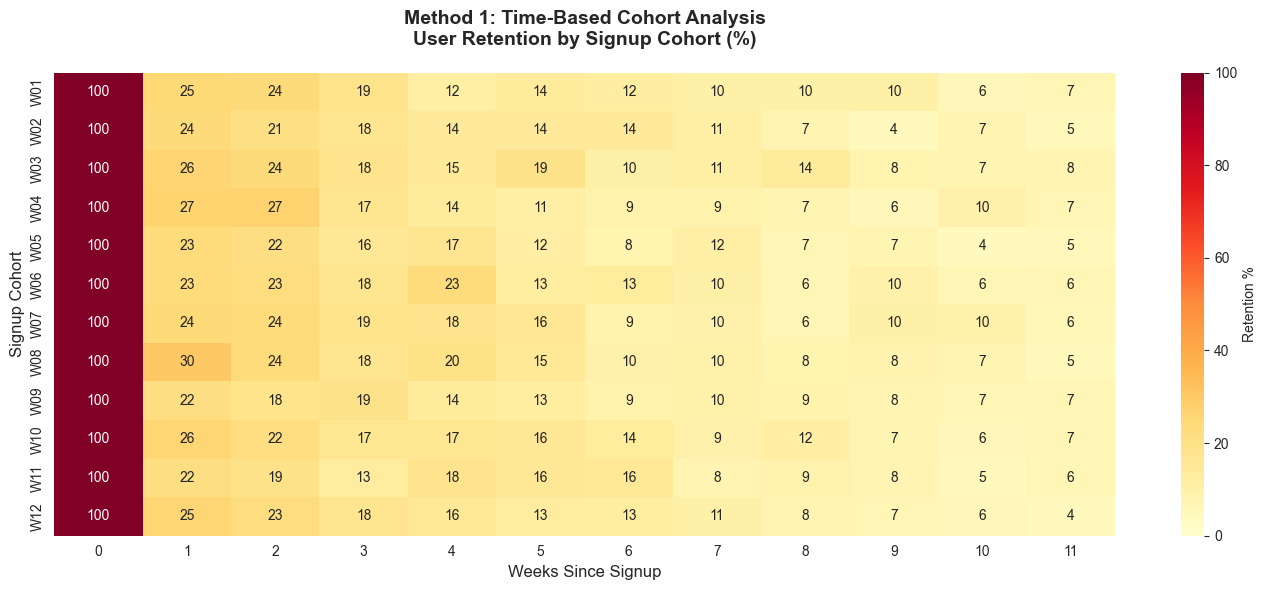

Saved: nb05_method1_timebased_heatmap.png


In [5]:
# Visualize Time-Based Cohort
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    retention_rate.iloc[:, :13],  # First 13 weeks
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Retention %'},
    ax=ax,
    vmin=0,
    vmax=100
)
ax.set_title('Method 1: Time-Based Cohort Analysis\nUser Retention by Signup Cohort (%)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Weeks Since Signup', fontsize=12)
ax.set_ylabel('Signup Cohort', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'nb05_method1_timebased_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Saved: nb05_method1_timebased_heatmap.png')

In [6]:
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

# Recreate time-based cohort heatmap as interactive Plotly
retention_rate_slice = retention_rate.iloc[:, :13]

fig = go.Figure(data=go.Heatmap(
    z=retention_rate_slice.values,
    x=retention_rate_slice.columns,
    y=retention_rate_slice.index,
    colorscale='YlOrRd',
    text=retention_rate_slice.values.round(0),
    texttemplate='%{text:.0f}',
    textfont={"size": 9},
    colorbar=dict(title=dict(text='Retention %', side='right')),
    hovertemplate='Cohort: %{y}<br>Week: %{x}<br>Retention: %{z:.1f}%<extra></extra>'
))

fig.update_layout(
    title='Method 1: Time-Based Cohort Analysis<br>User Retention by Signup Cohort (%)',
    xaxis_title='Weeks Since Signup',
    yaxis_title='Signup Cohort',
    height=600,
    template='plotly_white'
)

DATA_OUTPUT = Path('../data/outputs/nb05/')
fig.write_html(str(DATA_OUTPUT / 'nb05_method1_timebased_heatmap_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb05_method1_timebased_heatmap_interactive.html')

Saved: nb05_method1_timebased_heatmap_interactive.html


**Method 1: Benefits & Limitations**

**Benefits:**
- Simple and interpretable: Direct retention percentages
- Reveals seasonal or product change impacts on cohort quality
- Identifies whether newer cohorts are healthier or worse
- Industry standard for product health metrics

**Limitations:**
- Cannot explain *why* retention differs (behavioral patterns hidden)
- Does not account for user heterogeneity (power users vs casual)
- Confounds user acquisition changes with product changes
- May hide business model differences (free vs paid segments)

## Section 3: Method 2 - Behavioral Cohort Analysis

**Definition:** Users are segmented by their engagement level in the first week (power users, regular users, casual users), then retention is tracked across groups.

**Use Case:** Understanding how different user types have different lifecycle patterns. Useful for predicting LTV and targeting interventions.

**Metrics:** Retention curves by user engagement tier

In [7]:
# Behavioral Cohort: Classify users by first-week session count
# Get first week activity (0-6 days after signup)
first_week = df[df['weeks_since_signup'] == 0].copy()
first_week_sessions = first_week.groupby('user_id')['session_duration_sec'].count().reset_index()
first_week_sessions.columns = ['user_id', 'first_week_sessions']

# Classify users
def classify_user(session_count):
    if session_count >= 5:
        return 'Power User (5+)'
    elif session_count >= 2:
        return 'Regular User (2-4)'
    else:
        return 'Casual User (1)'

first_week_sessions['behavior_segment'] = first_week_sessions['first_week_sessions'].apply(classify_user)

# Merge back to main dataframe
df = df.merge(first_week_sessions[['user_id', 'behavior_segment']], on='user_id', how='left')

print('User Distribution by Behavior Segment:')
print(df[['user_id', 'behavior_segment']].drop_duplicates().groupby('behavior_segment').size())
print('\nExample data:')
print(df[['user_id', 'behavior_segment', 'weeks_since_signup']].head(10))

User Distribution by Behavior Segment:
behavior_segment
Casual User (1)       1723
Power User (5+)         64
Regular User (2-4)    1213
dtype: int64

Example data:
  user_id    behavior_segment  weeks_since_signup
0  C00001  Regular User (2-4)                   0
1  C00001  Regular User (2-4)                   0
2  C00001  Regular User (2-4)                   1
3  C00001  Regular User (2-4)                   1
4  C00001  Regular User (2-4)                   1
5  C00001  Regular User (2-4)                   1
6  C00001  Regular User (2-4)                   4
7  C00001  Regular User (2-4)                   4
8  C00001  Regular User (2-4)                   4
9  C00001  Regular User (2-4)                   4


In [8]:
# Behavioral Cohort: Retention curves by segment
behavioral_retention = df.groupby(['behavior_segment', 'weeks_since_signup']).agg({
    'user_id': 'nunique'
}).reset_index()
behavioral_retention.columns = ['behavior_segment', 'weeks_since_signup', 'active_users']

# Calculate retention rate within each segment
for segment in behavioral_retention['behavior_segment'].unique():
    segment_data = behavioral_retention[behavioral_retention['behavior_segment'] == segment]
    initial_size = segment_data[segment_data['weeks_since_signup'] == 0]['active_users'].values
    if len(initial_size) > 0:
        behavioral_retention.loc[
            behavioral_retention['behavior_segment'] == segment, 'retention_rate'
        ] = (behavioral_retention[behavioral_retention['behavior_segment'] == segment]['active_users'] / 
             initial_size[0] * 100)

print('Behavioral Cohort Retention Rates:')
for segment in sorted(behavioral_retention['behavior_segment'].unique()):
    segment_df = behavioral_retention[behavioral_retention['behavior_segment'] == segment]
    print(f'\n{segment}:')
    print(segment_df[['weeks_since_signup', 'active_users', 'retention_rate']].head(6).to_string(index=False))

Behavioral Cohort Retention Rates:

Casual User (1):
 weeks_since_signup  active_users  retention_rate
                  0          1723      100.000000
                  1           362       21.009867
                  2           349       20.255369
                  3           266       15.438189
                  4           254       14.741730
                  5           201       11.665699

Power User (5+):
 weeks_since_signup  active_users  retention_rate
                  0            64        100.0000
                  1            28         43.7500
                  2            17         26.5625
                  3            14         21.8750
                  4            17         26.5625
                  5            17         26.5625

Regular User (2-4):
 weeks_since_signup  active_users  retention_rate
                  0          1213      100.000000
                  1           356       29.348722
                  2           311       25.638912
        

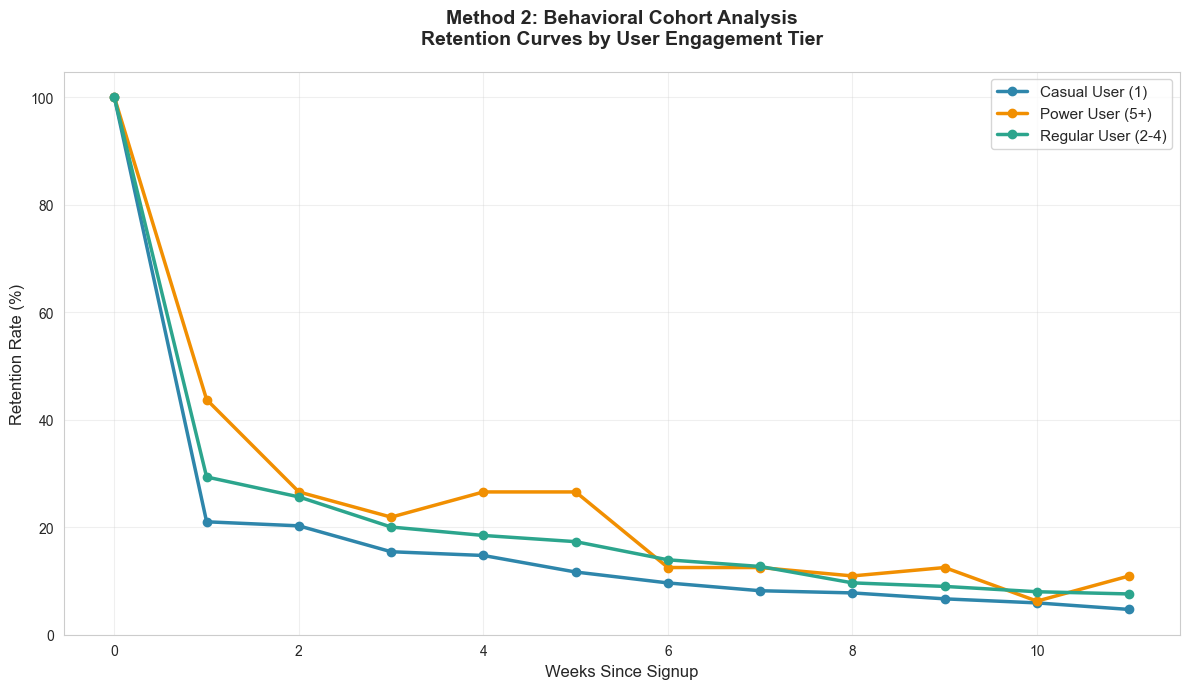

Saved: nb05_method2_behavioral_curves.png


In [9]:
# Visualize Behavioral Cohort
fig, ax = plt.subplots(figsize=(12, 7))

for i, segment in enumerate(sorted(behavioral_retention['behavior_segment'].unique())):
    segment_data = behavioral_retention[behavioral_retention['behavior_segment'] == segment]
    segment_data = segment_data[segment_data['weeks_since_signup'] <= 12]  # First 13 weeks
    ax.plot(
        segment_data['weeks_since_signup'],
        segment_data['retention_rate'],
        marker='o',
        linewidth=2.5,
        label=segment,
        color=colors[i]
    )

ax.set_xlabel('Weeks Since Signup', fontsize=12)
ax.set_ylabel('Retention Rate (%)', fontsize=12)
ax.set_title('Method 2: Behavioral Cohort Analysis\nRetention Curves by User Engagement Tier', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'nb05_method2_behavioral_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Saved: nb05_method2_behavioral_curves.png')

In [10]:
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

# Recreate behavioral cohort lines as interactive Plotly
fig = go.Figure()

for i, segment in enumerate(sorted(behavioral_retention['behavior_segment'].unique())):
    segment_data_py = behavioral_retention[behavioral_retention['behavior_segment'] == segment]
    segment_data_py = segment_data_py[segment_data_py['weeks_since_signup'] <= 12]
    
    fig.add_trace(go.Scatter(
        x=segment_data_py['weeks_since_signup'],
        y=segment_data_py['retention_rate'],
        mode='lines+markers',
        name=segment,
        line=dict(color=colors[i], width=2.5),
        marker=dict(size=8)
    ))

fig.update_layout(
    title='Method 2: Behavioral Cohort Analysis<br>Retention Curves by User Engagement Tier',
    xaxis_title='Weeks Since Signup',
    yaxis_title='Retention Rate (%)',
    hovermode='x unified',
    height=700,
    template='plotly_white'
)

DATA_OUTPUT = Path('../data/outputs/nb05/')
fig.write_html(str(DATA_OUTPUT / 'nb05_method2_behavioral_curves_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb05_method2_behavioral_curves_interactive.html')

Saved: nb05_method2_behavioral_curves_interactive.html


**Method 2: Benefits & Limitations**

**Benefits:**
- Reveals user heterogeneity: different user types have different trajectories
- Power users and casual users require different retention strategies
- Enables better LTV prediction and user valuation
- Guides product roadmap priorities (e.g., features for power users)

**Limitations:**
- Requires behavioral data from first week (may miss slower adopters)
- Threshold choices (5+, 2-4, 1) are arbitrary; need validation
- Segments may shift over time (a power user today might become casual)
- Does not account for other factors (acquisition channel, demographics)

## Section 4: Method 3 - Segment-Based Cohort Analysis

**Definition:** Users are grouped by their subscription plan (free, basic, pro), and retention is tracked separately for each business segment.

**Use Case:** Understanding how monetization strategy impacts retention. Different plans serve different user personas.

**Metrics:** Retention heatmaps by plan type

In [11]:
# Segment-Based Cohort: Group by plan_type
segment_retention = df.groupby(['plan_type', 'signup_cohort', 'weeks_since_signup']).agg({
    'user_id': 'nunique'
}).reset_index()
segment_retention.columns = ['plan_type', 'signup_cohort', 'weeks_since_signup', 'active_users']

print('Plan types available:')
print(sorted(df['plan_type'].unique()))
print('\nSample data by plan type:')
for plan in sorted(df['plan_type'].unique()):
    count = df[df['plan_type'] == plan]['user_id'].nunique()
    print(f'{plan}: {count} unique users')

Plan types available:
['basic', 'free', 'pro']

Sample data by plan type:
basic: 2027 unique users
free: 2491 unique users
pro: 1626 unique users


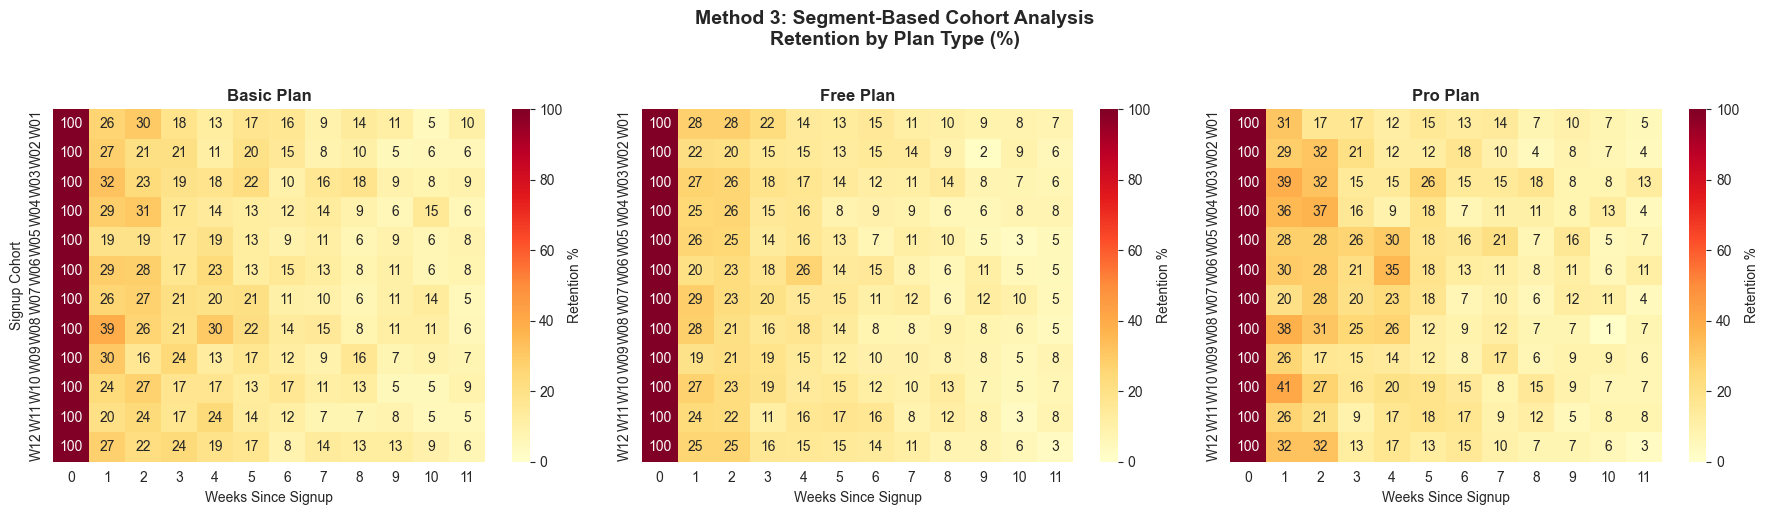

Saved: nb05_method3_segment_heatmaps.png


In [12]:
# Create retention heatmaps for each plan type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, plan_type in enumerate(sorted(df['plan_type'].unique())):
    # Filter data for this plan
    plan_data = segment_retention[segment_retention['plan_type'] == plan_type]
    
    # Pivot
    plan_pivot = plan_data.pivot(
        index='signup_cohort',
        columns='weeks_since_signup',
        values='active_users'
    ).fillna(0)
    
    # Calculate retention rate
    plan_cohort_size = plan_pivot.iloc[:, 0]
    plan_retention = plan_pivot.div(plan_cohort_size, axis=0) * 100
    
    # Plot heatmap
    sns.heatmap(
        plan_retention.iloc[:, :13],  # First 13 weeks
        annot=True,
        fmt='.0f',
        cmap='YlOrRd',
        cbar_kws={'label': 'Retention %'},
        ax=axes[idx],
        vmin=0,
        vmax=100
    )
    axes[idx].set_title(f'{plan_type.title()} Plan', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Weeks Since Signup', fontsize=10)
    axes[idx].set_ylabel('Signup Cohort' if idx == 0 else '', fontsize=10)

fig.suptitle('Method 3: Segment-Based Cohort Analysis\nRetention by Plan Type (%)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'nb05_method3_segment_heatmaps.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Saved: nb05_method3_segment_heatmaps.png')

In [13]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

# Recreate segment heatmaps as subplots in Plotly
plan_types = sorted(df['plan_type'].unique())
fig = make_subplots(1, 3, subplot_titles=[f'{pt.title()} Plan' for pt in plan_types])

for idx, plan_type in enumerate(plan_types, 1):
    plan_data_py = segment_retention[segment_retention['plan_type'] == plan_type]
    plan_pivot_py = plan_data_py.pivot(index='signup_cohort', columns='weeks_since_signup', values='active_users').fillna(0)
    plan_cohort_size = plan_pivot_py.iloc[:, 0]
    plan_retention = plan_pivot_py.div(plan_cohort_size, axis=0) * 100
    
    fig.add_trace(
        go.Heatmap(
            z=plan_retention.iloc[:, :13].values,
            x=plan_retention.iloc[:, :13].columns,
            y=plan_retention.index,
            colorscale='YlOrRd',
            text=plan_retention.iloc[:, :13].values.round(0),
            texttemplate='%{text:.0f}',
            textfont={"size": 8},
            colorbar=dict(title='Retention %', x=1.02),
            hovertemplate='Cohort: %{y}<br>Week: %{x}<br>Retention: %{z:.1f}%<extra></extra>',
            showscale=(idx==3)
        ),
        row=1, col=idx
    )

fig.update_xaxes(title_text='Weeks Since Signup', row=1, col=2)
fig.update_yaxes(title_text='Signup Cohort', row=1, col=1)

fig.update_layout(
    title_text='Method 3: Segment-Based Cohort Analysis<br>Retention by Plan Type (%)',
    height=500,
    template='plotly_white'
)

DATA_OUTPUT = Path('../data/outputs/nb05/')
fig.write_html(str(DATA_OUTPUT / 'nb05_method3_segment_heatmaps_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb05_method3_segment_heatmaps_interactive.html')

Saved: nb05_method3_segment_heatmaps_interactive.html


**Method 3: Benefits & Limitations**

**Benefits:**
- Isolates business model impact: free vs paid users behave differently
- Identifies upsell opportunities: understand free-to-paid conversion patterns
- Guides pricing strategy: which tier has best unit economics?
- Enables retention targeting: customize campaigns by segment

**Limitations:**
- Plan type may change during user lifecycle (not static)
- Sample size shrinks for smaller segments, increasing noise
- Does not explain causality: does plan drive retention or vice versa?
- May conflate user quality with pricing tier

## Section 5: Method 4 - Cohort Lifetime Value (Engagement)

**Definition:** Aggregate engagement (measured by cumulative session duration) is tracked per signup cohort over time to estimate user value.

**Use Case:** Understanding revenue potential and monetization curves by cohort. Which cohorts generate the most value?

**Metrics:** Cumulative session duration (proxy for engagement/revenue)

In [14]:
# Cohort LTV: Cumulative session_duration_sec per cohort
ltv_data = df.groupby(['signup_cohort', 'weeks_since_signup']).agg({
    'session_duration_sec': 'sum',
    'user_id': 'nunique'
}).reset_index()
ltv_data.columns = ['signup_cohort', 'weeks_since_signup', 'total_session_duration', 'active_users']

# Calculate cumulative duration
ltv_data = ltv_data.sort_values(['signup_cohort', 'weeks_since_signup'])
ltv_data['cumulative_session_duration'] = ltv_data.groupby('signup_cohort')['total_session_duration'].cumsum()

# Normalize by cohort size for fair comparison
for cohort in ltv_data['signup_cohort'].unique():
    cohort_size = ltv_data[(ltv_data['signup_cohort'] == cohort) & (ltv_data['weeks_since_signup'] == 0)]['active_users'].values
    if len(cohort_size) > 0:
        ltv_data.loc[ltv_data['signup_cohort'] == cohort, 'ltv_per_user'] = (
            ltv_data[ltv_data['signup_cohort'] == cohort]['cumulative_session_duration'] / cohort_size[0]
        )

print('Cohort LTV (Cumulative Session Duration) - Sample:')
print(ltv_data[ltv_data['weeks_since_signup'] <= 4].head(20))

Cohort LTV (Cumulative Session Duration) - Sample:
   signup_cohort  weeks_since_signup  total_session_duration  active_users  \
0            W01                   0                 80911.1           226   
1            W01                   1                 29732.3            57   
2            W01                   2                 23738.5            54   
3            W01                   3                 18747.3            43   
4            W01                   4                 12441.9            26   
12           W02                   0                 97577.8           254   
13           W02                   1                 36015.4            61   
14           W02                   2                 20426.6            53   
15           W02                   3                 17257.3            45   
16           W02                   4                 13620.0            36   
24           W03                   0                102133.7           224   
25           

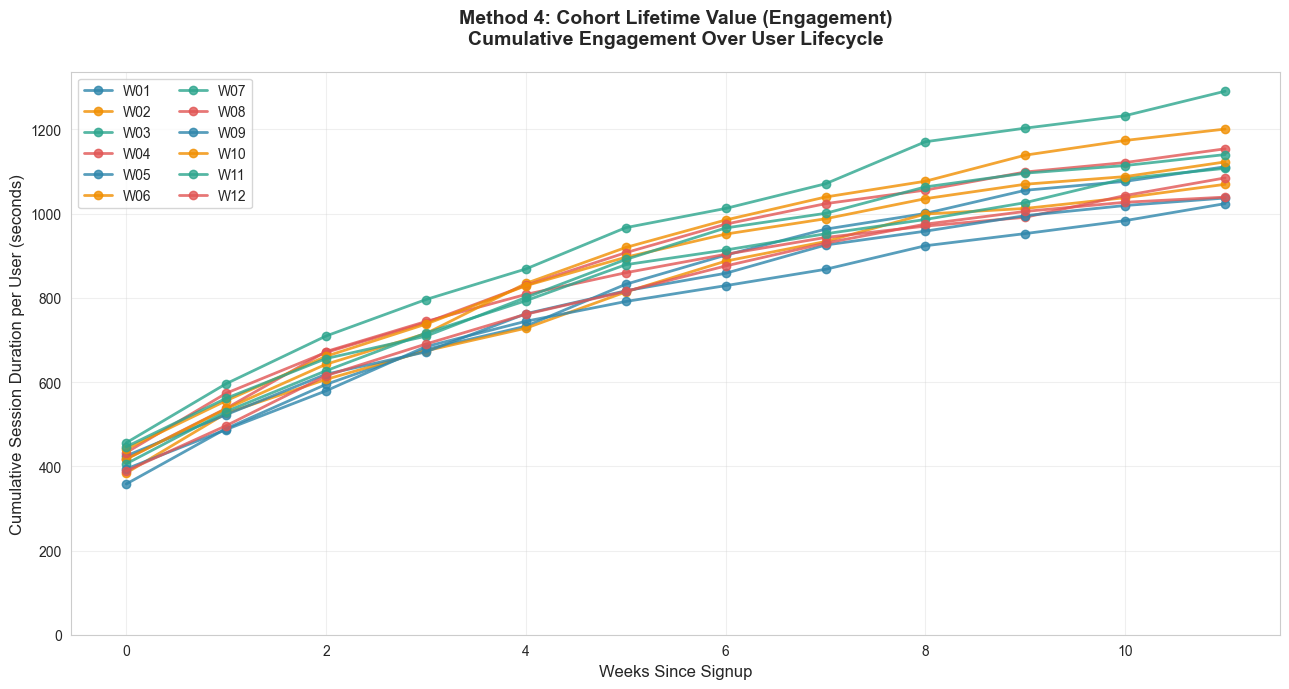

Saved: nb05_method4_ltv_curves.png


In [15]:
# Visualize Cohort LTV
fig, ax = plt.subplots(figsize=(13, 7))

for i, cohort in enumerate(sorted(df['signup_cohort'].unique())):
    cohort_ltv = ltv_data[ltv_data['signup_cohort'] == cohort]
    cohort_ltv = cohort_ltv[cohort_ltv['weeks_since_signup'] <= 12]  # First 13 weeks
    
    # Use modulo to cycle through colors if more than 4 cohorts
    color = colors[i % len(colors)]
    ax.plot(
        cohort_ltv['weeks_since_signup'],
        cohort_ltv['ltv_per_user'],
        marker='o',
        linewidth=2,
        label=cohort,
        alpha=0.8,
        color=color
    )

ax.set_xlabel('Weeks Since Signup', fontsize=12)
ax.set_ylabel('Cumulative Session Duration per User (seconds)', fontsize=12)
ax.set_title('Method 4: Cohort Lifetime Value (Engagement)\nCumulative Engagement Over User Lifecycle', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=10, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'nb05_method4_ltv_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Saved: nb05_method4_ltv_curves.png')

In [16]:
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

# Recreate LTV curves as interactive Plotly
fig = go.Figure()

for i, cohort in enumerate(sorted(df['signup_cohort'].unique())):
    cohort_ltv_py = ltv_data[ltv_data['signup_cohort'] == cohort]
    cohort_ltv_py = cohort_ltv_py[cohort_ltv_py['weeks_since_signup'] <= 12]
    color = colors[i % len(colors)]
    
    fig.add_trace(go.Scatter(
        x=cohort_ltv_py['weeks_since_signup'],
        y=cohort_ltv_py['ltv_per_user'],
        mode='lines+markers',
        name=cohort,
        line=dict(color=color, width=2),
        marker=dict(size=6),
        opacity=0.8
    ))

fig.update_layout(
    title='Method 4: Cohort Lifetime Value (Engagement)<br>Cumulative Engagement Over User Lifecycle',
    xaxis_title='Weeks Since Signup',
    yaxis_title='Cumulative Session Duration per User (seconds)',
    hovermode='x unified',
    height=700,
    template='plotly_white'
)

DATA_OUTPUT = Path('../data/outputs/nb05/')
fig.write_html(str(DATA_OUTPUT / 'nb05_method4_ltv_curves_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb05_method4_ltv_curves_interactive.html')

Saved: nb05_method4_ltv_curves_interactive.html


**Method 4: Benefits & Limitations**

**Benefits:**
- Direct revenue proxy: session duration correlates with platform value
- Reveals monetization quality: newer cohorts vs historical cohorts
- Guides user acquisition ROI: is CAC justified by LTV?
- Identifies market saturation or competitive threats (declining LTV)

**Limitations:**
- Requires long observation windows to see full LTV (expensive to wait)
- Session duration is imperfect revenue proxy (need actual ARPU for accuracy)
- Assumes static behavior (user engagement may change over time)
- Cohorts need sufficient size for stable LTV estimates

## Section 6: Method Comparison Table

| **Method** | **Cohort Definition** | **Key Metric** | **Use Case** | **Pros** | **Cons** |
|---|---|---|---|---|---|
| **Time-Based** | Signup week | Retention % | Baseline health by signup time | Simple, interpretable, standard | Cannot explain why (behavioral blind spot) |
| **Behavioral** | First-week engagement level | Retention by user tier | Predict LTV, target interventions | User heterogeneity visible | Threshold choices arbitrary |
| **Segment-Based** | Plan type (free/paid) | Retention by business model | Monetization strategy impact | Business model isolation | Plan may change, small samples |
| **LTV** | Signup week + engagement | Cumulative session duration | Revenue potential per cohort | Direct value signal | Need long observation window |

## Section 7: Key Findings & Recommendations

### Insights from the Data

1. **Cohort Quality Trends**: Examine the time-based heatmap for rows (cohorts). Are earlier cohorts healthier? This suggests product improvement or market saturation.

2. **User Segmentation**: The behavioral and segment-based methods reveal that not all users are equal. Power users and paid plans likely show different retention curves.

3. **Monetization Opportunity**: Compare free vs paid retention. If paid users retain better, upsell may be key to unit economics.

4. **Engagement Quality**: The LTV curves show cumulative value over time. Steep curves indicate strong engagement; flat curves suggest churn risk.

### Actionable Recommendations

- **Investigate Cohort Inflection Points**: If retention drops sharply at week X across all cohorts, this points to a product issue or churn trigger.

- **Target Power Users**: Behavioral cohorts reveal that high-engagement users are gold. Design retention features for them.

- **Optimize Free-to-Paid Funnel**: Use segment-based cohorts to identify barriers to upgrade. Which free users convert to paid?

- **Monitor New Cohort Health**: Always compare the most recent cohort to historical average. Degradation signals acquisition or product issues.

- **Combine Methods**: No single method is complete. Use all four perspectives to triangulate insights.

## Section 8: Summary

Cohort analysis is a cornerstone of product analytics. By grouping users and tracking their behavior over time, product teams can:

- Measure retention and engagement objectively
- Identify the impact of product changes (new features, pricing, UX)
- Segment users by value and behavior
- Forecast revenue and unit economics

This notebook demonstrated four complementary methods, each revealing different aspects of user behavior. In practice, use them together to build a complete picture of your user lifecycle.